<div style="display:flex; align-items:center; gap:18px; text-align:left">
<img src="https://sebastiancontz.github.io/ust-introduccion-machine-learning/assets/logo-ust.svg" width="100" alt="Logo de la Universidad Santo Tomás">
<div>
<p>Ingeniería en Información y Control de Gestión</p>
<p>Facultad de Economía y Negocios</p>
<p>Introducción a Machine Learning</p>
<p>Semana 07: Regresión predictiva — baseline, métricas y regularización</p>
</div>
</div>

# 07 · Regresión predictiva: baseline, métricas y regularización

El flujo de la clase anterior no cambia. Lo único que cambia hoy es **la última pieza** del
`Pipeline`, y con eso alcanza para recorrer cuatro modelos.

In [1]:
%%capture
!pip install -q pandas numpy pyarrow scikit-learn

In [2]:
import os

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from IPython.display import Markdown, display

In [3]:
def num(x, dec=0):
    """miles con punto, decimales con coma y el menos tipográfico, como el resto del material"""
    texto = f'{x:,.{dec}f}'.replace(',', '@').replace('.', ',').replace('@', '.')
    return texto.replace('-', '−')

def dos(x):
    """la versión de dos decimales que usan las tablas"""
    return num(x, 2)

## El encuadre, declarado antes de tocar el archivo

Sin esto la actividad no se puede evaluar, así que va primero y en voz alta:

- La **unidad de observación es el cliente**. Un registro es un cliente, no una factura ni una línea
  de factura.
- El **objetivo es un conteo**: cuántas veces vuelve a comprar cada cliente en la ventana futura.
- El **momento de la predicción** es el corte entre las dos ventanas. Las fuentes permitidas son solo
  lo anterior a él.
- Por eso la **población no se filtra por lo que pasó después**. El cliente que no vuelve **vale
  cero**, no desaparece del archivo. Filtrarlo sería seleccionar por el resultado, que es justo la
  falta que la clase anterior enseñó a detectar.

### Cargar el archivo

Un archivo por cliente, construido y versionado, con el corte temporal ya aplicado.

<!-- contrato: accion=fijar-base -->

In [4]:
REPO = 'https://raw.githubusercontent.com/sebastiancontz/ust-introduccion-machine-learning-colab/main/ediciones/2026/datasets/'
BASE = '../datasets/' if os.path.exists('../datasets') else REPO

clientes = pd.read_parquet(BASE + 'clientes_ventas.parquet')
print('Filas y columnas:', clientes.shape)
clientes.head()

Filas y columnas: (3314, 9)


,id_cliente,facturas_base,monto_base,productos_base,ticket_medio_base,recencia_dias,antiguedad_dias,mercado,facturas_futuras
0,12346,1,77183.60,1,77183.60,225,225,reino unido,0
1,12347,5,2790.86,82,558.17,29,267,exportacion,2
2,12348,3,1167.24,21,389.08,148,258,exportacion,1
3,12350,1,294.40,16,294.40,210,210,exportacion,0
4,12352,4,641.51,24,160.38,162,196,exportacion,3


In [5]:
ceros = int((clientes['facturas_futuras'] == 0).sum())
display(Markdown(
    f'De los **{num(len(clientes))}** clientes del archivo, **{num(ceros)}** no vuelven a comprar en '
    f'la ventana futura: el **{num(100 * ceros / len(clientes))} %**. Son la mayor parte de la '
    f'distribución del objetivo y no se pueden sacar.'
))

De los **3.314** clientes del archivo, **1.367** no vuelven a comprar en la ventana futura: el **41 %**. Son la mayor parte de la distribución del objetivo y no se pueden sacar.

### La partición, igual que la clase anterior

Tres pedazos y cada uno con su trabajo. **Entrenamiento** ajusta, **validación** decide entre
alternativas, y **prueba** se abre **una sola vez** cuando ya no queda nada por decidir.

Que validación exista es lo que nos va a permitir elegir un parámetro sin hacer trampa. Si lo
eligiéramos mirando prueba, el error que reportamos dejaría de estimar lo que va a pasar con clientes
nuevos: quedaría optimista por construcción.

<!-- contrato: accion=partir-en-tres -->

In [6]:
COLUMNAS_NUM = ['facturas_base', 'monto_base', 'productos_base',
                'ticket_medio_base', 'recencia_dias', 'antiguedad_dias']
COLUMNAS_CAT = ['mercado']

X = clientes[COLUMNAS_NUM + COLUMNAS_CAT]
y = clientes['facturas_futuras']

# 20 % a prueba, y del resto un 25 % a validación: quedan 60 / 20 / 20
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=42)

print('entrenamiento:', len(X_train), '· validación:', len(X_val), '· prueba:', len(X_test))

entrenamiento: 1988 · validación: 663 · prueba: 663


<p align="center"></p>

Las dos líneas de arriba son **dos cortes, no uno**. El segundo cae solo sobre el pedazo izquierdo
del primero, y por eso `test_size=0.25` sobre el 80 % que quedaba deja un 20 % del total.

Prueba no se toca en ninguno de los dos pasos siguientes. Ésa es toda la disciplina.

# Tiempo 1 · Yo lo hago

## El baseline primero, y con la estrategia que corresponde

La clase anterior ya usó un predictor constante para leer sus cifras contra algo. Hoy ese baseline
deja de ser un dato al costado: es el **competidor**.

El flujo es el mismo de la clase pasada, con un interruptor nuevo: `StandardScaler` deja todas las
columnas numéricas en la misma escala. Hoy va apagado —el modelo lineal no lo necesita— y se enciende
más abajo, cuando entren Ridge y Lasso, que sí lo exigen.

Y antes de entrenar hay que **declarar la métrica**, no después. Nuestra vara es el **promedio del
error absoluto, en facturas por cliente**.

<!-- contrato: accion=armar-el-flujo -->

In [7]:
def preparador(escalar=False):
    """el ColumnTransformer de la clase 5, con el escalado como interruptor"""
    return ColumnTransformer([
        ('num', StandardScaler() if escalar else 'passthrough', COLUMNAS_NUM),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), COLUMNAS_CAT),
    ])

def flujo(estimador, escalar=False):
    """el mismo Pipeline de siempre: lo único que cambia es la última pieza"""
    return Pipeline([('pre', preparador(escalar)), ('est', estimador)])

La métrica declarada tiene una consecuencia que casi nunca se dice: **para un predictor constante,
cada vara tiene su campeón**. El promedio minimiza el error al cuadrado y la mediana minimiza el
error absoluto. Como medimos con la absoluta, el baseline que corresponde es la **mediana**.

Vamos a calcular los dos para que se vea que no da lo mismo.

<!-- contrato: accion=el-baseline -->

In [8]:
piso_promedio = flujo(DummyRegressor(strategy='mean')).fit(X_train, y_train)
piso_mediana = flujo(DummyRegressor(strategy='median')).fit(X_train, y_train)

# mean_absolute_error recibe primero lo observado y después lo predicho, en ese orden
mae_promedio = mean_absolute_error(y_val, piso_promedio.predict(X_val))
mae_mediana = mean_absolute_error(y_val, piso_mediana.predict(X_val))
print('predecir siempre el promedio:', dos(mae_promedio))
print('predecir siempre la mediana: ', dos(mae_mediana))

predecir siempre el promedio: 1,55
predecir siempre la mediana:  1,39


In [9]:
display(Markdown(
    f'Con nuestra vara, el baseline del promedio se equivoca en **{dos(mae_promedio)}** facturas y el '
    f'de la mediana en **{dos(mae_mediana)}**. Elegir el del promedio nos daría un rival debilitado, y '
    f'todo lo que el modelo le gane de más sería mérito prestado. Seguimos con la **mediana**.'
))

Con nuestra vara, el baseline del promedio se equivoca en **1,55** facturas y el de la mediana en **1,39**. Elegir el del promedio nos daría un rival debilitado, y todo lo que el modelo le gane de más sería mérito prestado. Seguimos con la **mediana**.

## Ahora cambiamos la última pieza

El flujo es el mismo. `DummyRegressor` sale y entra `LinearRegression`, que es el modelo que vieron
en Estadística y Econometría, ahora con otro propósito: **predecir**, no explicar.

<!-- contrato: accion=el-modelo -->

In [10]:
lineal = flujo(LinearRegression()).fit(X_train, y_train)
mae_lineal = mean_absolute_error(y_val, lineal.predict(X_val))

display(Markdown(
    f'El baseline de la mediana estaba en **{dos(mae_mediana)}** facturas de error. El modelo lineal '
    f'baja a **{dos(mae_lineal)}**: le gana por **{dos(mae_mediana - mae_lineal)}**. Recién ahora esa '
    f'cifra de error significa algo, porque tiene contra qué leerse.'
))

El baseline de la mediana estaba en **1,39** facturas de error. El modelo lineal baja a **1,11**: le gana por **0,28**. Recién ahora esa cifra de error significa algo, porque tiene contra qué leerse.

### El flujo, dibujado

Escribir el objeto lo dibuja. Van a ver el `Pipeline` con sus dos pasos y, dentro del primero, el
`ColumnTransformer` repartiendo las columnas. Hagan clic en cualquier caja para desplegarla.

Sirve para verificar de un vistazo que **la última pieza es la que creen**. Es el mismo diagrama de
la clase pasada: lo único distinto hoy es lo que dice el último recuadro.

In [11]:
lineal

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('est', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['facturas_base','monto_base','productos_base',...,'recencia_dias', 'antiguedad_dias','mercado']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subse

### Leer los coeficientes, con una cautela

`coef_` guarda un número por columna del modelo ya ajustado, y `get_feature_names_out` nos dice a
qué columna corresponde cada uno. Los juntamos para poder leerlos, y los ordenamos con `sort_values`
por **tamaño** y no por signo: un coeficiente negativo grande mueve la predicción tanto como uno
positivo grande.

**La cautela:** un coeficiente describe una **asociación condicional**, no un efecto. Decir «con todo
lo demás igual» está bien; decir «si subimos esta variable, el objetivo sube» no lo está, porque
nadie intervino nada.

In [12]:
nombres = lineal.named_steps['pre'].get_feature_names_out()
coeficientes = pd.DataFrame({'coeficiente': lineal.named_steps['est'].coef_}, index=nombres)
# ordenados por tamaño, sin importar el signo: los grandes son los que mueven la predicción
coeficientes = coeficientes.sort_values('coeficiente', key=abs, ascending=False)
coeficientes

,coeficiente
num__facturas_base,0.460019
cat__mercado_reino unido,-0.123321
num__productos_base,0.007761
num__antiguedad_dias,-0.006639
num__recencia_dias,0.004162
num__ticket_medio_base,-0.000385
num__monto_base,0.000119


In [13]:
principal = coeficientes.index[0]
valor = coeficientes['coeficiente'].iloc[0]
display(Markdown(
    f'El coeficiente más grande en magnitud es **{principal}**, con **{num(valor, 3)}**. Se lee así: '
    f'entre dos clientes que coinciden en todo lo demás, el que tiene una unidad más de esa variable '
    f'compra en promedio {num(valor, 3)} facturas más en la ventana futura. Es una comparación entre '
    f'clientes, no el resultado de intervenir sobre uno.'
))

El coeficiente más grande en magnitud es **num__facturas_base**, con **0,460**. Se lee así: entre dos clientes que coinciden en todo lo demás, el que tiene una unidad más de esa variable compra en promedio 0,460 facturas más en la ventana futura. Es una comparación entre clientes, no el resultado de intervenir sobre uno.

# Tiempo 2 · Lo hacemos juntos

## Dos métricas en la misma tabla

Hasta acá usamos una sola vara. Ahora le ponemos nombre a las dos que vamos a usar:

- **MAE** (*mean absolute error*), el **promedio del error absoluto**. Es la que veníamos usando.
- **RMSE** (*root mean squared error*), la **raíz del error cuadrático medio**. Eleva cada error al
  cuadrado antes de promediar, así que un error grande pesa mucho más que varios chicos.

`mean_absolute_error` y `root_mean_squared_error` las calculan, y las dos reciben lo mismo y en el
mismo orden: primero lo **observado** y después lo **predicho**. Hasta ahora solo usamos la primera.

<!-- contrato: accion=metricas-con-nombre -->

In [14]:
dos_modelos = {'baseline (mediana)': piso_mediana, 'regresión lineal': lineal}

filas = []
for nombre, modelo in dos_modelos.items():
    prediccion = modelo.predict(X_val)
    filas.append({'modelo': nombre,
                  'MAE': mean_absolute_error(y_val, prediccion),
                  'RMSE': root_mean_squared_error(y_val, prediccion)})

tabla = pd.DataFrame(filas)
tabla.round(2)

,modelo,MAE,RMSE
0,baseline (mediana),1.39,2.50
1,regresión lineal,1.11,1.66


In [15]:
display(Markdown(
    f'En las dos filas el RMSE es más alto que el MAE: '
    f'**{dos(root_mean_squared_error(y_val, lineal.predict(X_val)))}** contra '
    f'**{dos(mean_absolute_error(y_val, lineal.predict(X_val)))}** en el modelo. No es un error y '
    f'no es casualidad: la diferencia entre las dos crece cuando hay **errores grandes y pocos**. '
    f'Nuestro objetivo tiene cola larga, así que los hay.'
))

En las dos filas el RMSE es más alto que el MAE: **1,66** contra **1,11** en el modelo. No es un error y no es casualidad: la diferencia entre las dos crece cuando hay **errores grandes y pocos**. Nuestro objetivo tiene cola larga, así que los hay.

### Y ahora véanlo, cliente por cliente

Las cifras dicen que el modelo le gana al baseline. El gráfico dice **por qué**, y también dónde
falla: cada punto es un cliente de validación, con lo observado en el eje horizontal y lo predicho en
el vertical.

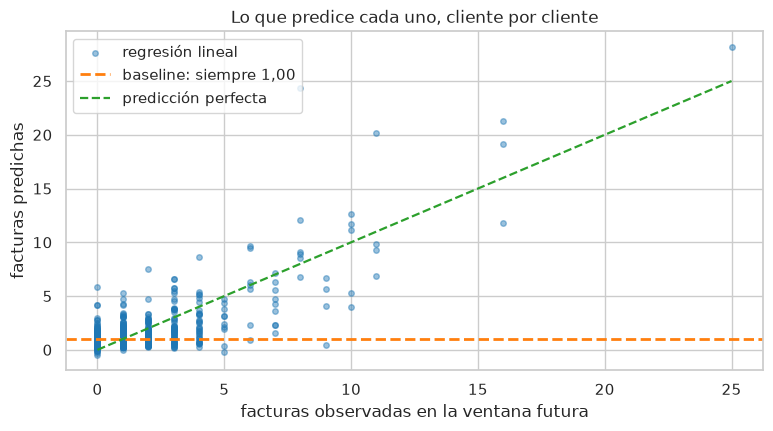

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='tab10')

prediccion_modelo = lineal.predict(X_val)
constante = piso_mediana.predict(X_val)[0]   # el baseline predice lo mismo para todos

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.scatter(y_val, prediccion_modelo, s=16, alpha=0.45, color='tab:blue',
           label='regresión lineal')
ax.axhline(constante, color='tab:orange', linestyle='--', lw=2,
           label=f'baseline: siempre {dos(constante)}')
ax.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()],
        color='tab:green', linestyle='--', lw=1.6, label='predicción perfecta')
ax.set_xlabel('facturas observadas en la ventana futura')
ax.set_ylabel('facturas predichas')
ax.set_title('Lo que predice cada uno, cliente por cliente')
ax.legend()
plt.show()

Dos cosas para leer ahí:

- **El baseline es una raya horizontal.** Predice lo mismo para todos, así que no puede distinguir ni
  ordenar a nadie. Los puntos azules, en cambio, suben con el cliente: eso es lo que el modelo aporta,
  y se ve aunque la diferencia de error fuera chica.
- **La nube sigue a la diagonal verde, pero ancha.** El modelo le acierta a la tendencia y le erra al
  detalle. Cuánto le erra en el peor caso lo calculamos abajo, porque a ojo se subestima.

In [17]:
error_por_cliente = abs(y_val - prediccion_modelo)
peor = error_por_cliente.idxmax()
display(Markdown(
    f'El peor caso de validación es un cliente que compró **{num(y_val[peor])}** veces y al que el '
    f'modelo le predijo **{dos(prediccion_modelo[y_val.index.get_loc(peor)])}**: se equivocó por '
    f'**{dos(error_por_cliente[peor])}** facturas. Errores así hay pocos, y son exactamente los que '
    f'levantan el RMSE por encima del MAE.'
))

El peor caso de validación es un cliente que compró **8** veces y al que el modelo le predijo **24,36**: se equivocó por **16,36** facturas. Errores así hay pocos, y son exactamente los que levantan el RMSE por encima del MAE.

## Ponerle precio a la complejidad

Ridge y Lasso son el mismo modelo lineal con un **peaje** añadido: además de acercarse a los datos,
tienen que mantener chicos sus coeficientes.

- `Ridge` penaliza los coeficientes **al cuadrado**. Los encoge a todos y ninguno sale del modelo.
- `Lasso` penaliza su **valor absoluto**. Encoge y además lleva algunos exactamente a cero, con lo
  cual saca variables.

Las dos **exigen escalar** las variables, y por eso el `preparador` tiene ese interruptor:
`StandardScaler` deja todas las columnas numéricas en la misma escala. Sin eso, la penalización
castigaría a la variable que quedó con números grandes por su unidad, no por su importancia.

### Y el alpha se elige sobre validación

> **Antes de correr esto, un aviso.** Este cuaderno parte el archivo en **tres** y las slides lo
> parten en **dos**, porque allá no hacía falta un conjunto para elegir el alpha. Como la partición
> es otra, **el alpha que gane acá puede no ser el de las slides**. Eso no es un error: es
> exactamente lo que dice el cierre de la clase, que un corte al azar tiene su propia suerte. Cuando
> vean la diferencia, esa es la lección, no una contradicción.

`alpha` es el precio del peaje. Dos cosas antes de moverlo:

1. **Cada modelo tiene su propia escala de alpha.** No son comparables entre sí, así que cada uno va
   con su grilla. Buscarlos en una grilla común es la forma más rápida de concluir algo falso.
2. **La elección se hace sobre validación**, con prueba todavía cerrada. Elegir el que da el mejor
   error de prueba y después reportar ese mismo error es hacerse trampa a uno mismo.

<!-- contrato: accion=elegir-alpha -->

In [18]:
ALPHAS_RIDGE = [10.0, 100.0, 1000.0]
ALPHAS_LASSO = [0.01, 0.1, 1.0]

def elegir(Estimador, alphas):
    """mide cada candidato sobre validación y devuelve el mejor con sus filas"""
    filas = []
    mejor_alpha = None
    mejor_error = None
    for a in alphas:
        candidato = flujo(Estimador(alpha=a), escalar=True).fit(X_train, y_train)
        error = mean_absolute_error(y_val, candidato.predict(X_val))
        filas.append({'alpha': a, 'MAE en validación': error})
        # nos quedamos con el alpha del error más chico
        if mejor_error is None or error < mejor_error:
            mejor_alpha = a
            mejor_error = error
    return mejor_alpha, filas

alpha_ridge, filas_ridge = elegir(Ridge, ALPHAS_RIDGE)
alpha_lasso, filas_lasso = elegir(Lasso, ALPHAS_LASSO)
print('alpha elegido para Ridge:', alpha_ridge)
print('alpha elegido para Lasso:', alpha_lasso)

alpha elegido para Ridge: 1000.0
alpha elegido para Lasso: 1.0


In [19]:
todas = []
for nombre, filas in [('Ridge', filas_ridge), ('Lasso', filas_lasso)]:
    for fila in filas:
        todas.append({'modelo': nombre,
                      'alpha': fila['alpha'],
                      'MAE en validación': fila['MAE en validación']})

pd.DataFrame(todas).round(4)

,modelo,alpha,MAE en validación
0,Ridge,10.00,1.1074
1,Ridge,100.00,1.0947
2,Ridge,1000.00,1.0879
3,Lasso,0.01,1.1045
4,Lasso,0.10,1.0803
5,Lasso,1.00,1.0464


In [20]:
ridge = flujo(Ridge(alpha=alpha_ridge), escalar=True).fit(X_train, y_train)
lasso = flujo(Lasso(alpha=alpha_lasso), escalar=True).fit(X_train, y_train)

coef_lasso = pd.DataFrame({'coeficiente': lasso.named_steps['est'].coef_}, index=nombres)
en_cero = list(coef_lasso[coef_lasso['coeficiente'].abs() < 1e-10].index)
# no lo afirmamos: lo contamos, igual que el de Lasso
vivos_ridge = int((abs(ridge.named_steps['est'].coef_) > 1e-10).sum())
display(Markdown(
    f'Lasso con alpha {alpha_lasso} llevó a cero **{len(en_cero)} de {len(coef_lasso)}** coeficientes: '
    f'{", ".join(f"`{c}`" for c in en_cero) if en_cero else "ninguno"}. Ridge, en cambio, conserva '
    f'{vivos_ridge} de {len(coef_lasso)}: encogió, pero no sacó a nadie.'
))

Lasso con alpha 1.0 llevó a cero **6 de 7** coeficientes: `num__monto_base`, `num__productos_base`, `num__ticket_medio_base`, `num__recencia_dias`, `num__antiguedad_dias`, `cat__mercado_reino unido`. Ridge, en cambio, conserva 7 de 7: encogió, pero no sacó a nadie.

# Tiempo 3 · Lo hacen ustedes

## La decisión

Tienen cuatro modelos sobre la mesa y hay que **llevar uno a una gerencia**. La actividad es
decidirlo y defenderlo por escrito en **tres líneas**.

La decisión **no es obvia**, y ahí está el punto. Miren la tabla de alpha que calcularon más arriba
antes de responder:

- El MAE más bajo es **un** argumento, y no siempre gana por mucho.
- Un modelo que usa **menos columnas** es más fácil de explicar y de mantener. Ése es un argumento
  distinto —**simplicidad**— y hay que decidir cuánto pesa cuando la diferencia de error es chica.
- Y ojo con esto: **el alpha lo eligió un solo corte de validación**. Con otra partición al azar el
  ganador puede ser otro. Cuánta confianza le dan a esa elección es parte de la decisión.

**Criterio de éxito:** elegir el baseline que corresponde a la métrica y justificarlo; leer MAE y
RMSE y explicar por qué difieren; nombrar qué le hace la penalización a los coeficientes y en qué se
diferencian Ridge y Lasso; y defender una elección de modelo con la tabla delante.

**Evidencia observable:** la tabla comparativa de los cuatro modelos con sus dos métricas, la lista
de coeficientes que Lasso llevó a cero, y las tres líneas de la decisión justificada.

**Y una trampa que tienen que ver antes de mirar la tabla.** Las filas de Ridge y Lasso están
**infladas a su favor**: su alpha se eligió mirando validación, y esta tabla también mide sobre
validación. Es la misma falta que estudiamos, en versión chica. Por eso la tabla sirve para *decidir*
—que es lo que hay que hacer con datos que no son de prueba— pero **no** para reportar el desempeño.
Ese número llega al final, y va a ser peor.

In [21]:
# armen la tabla de los CUATRO modelos sobre validación y mírenla antes de decidir
cuatro_modelos = {'baseline (mediana)': piso_mediana,
                  'regresión lineal': lineal,
                  f'ridge (alpha={alpha_ridge})': ridge,
                  f'lasso (alpha={alpha_lasso})': lasso}

filas = []
for nombre, modelo in cuatro_modelos.items():
    prediccion = modelo.predict(X_val)
    filas.append({'modelo': nombre,
                  'MAE': mean_absolute_error(y_val, prediccion),
                  'RMSE': root_mean_squared_error(y_val, prediccion)})

comparacion = pd.DataFrame(filas)
# el baseline no usa ninguna columna; los otros usan las que no quedaron en cero
comparacion['columnas'] = [0, len(nombres), len(nombres), len(nombres) - len(en_cero)]
comparacion.round(2)

,modelo,MAE,RMSE,columnas
0,baseline (mediana),1.39,2.50,0
1,regresión lineal,1.11,1.66,7
2,ridge (alpha=1000.0),1.09,1.60,7
3,lasso (alpha=1.0),1.05,1.44,1


### Su respuesta

Escriban acá las tres líneas. Qué modelo llevarían, con qué cifra lo sostienen, y qué renuncian al
elegirlo.

1.
2.
3.

# Cierre

## Abrir la prueba, una sola vez

Ya no queda nada por decidir: la métrica está declarada, el baseline elegido y los alpha fijados
sobre validación.

Falta **un paso** antes de medir, y es el que más se olvida. Validación ya hizo su trabajo: eligió el
alpha. Así que ahora se **reajustan los cuatro modelos con todo el entrenamiento** —entrenamiento más
validación— y recién esos son los que se llevan a prueba. Reservar 663 clientes que ya no hacen falta
sería tirar datos.

In [22]:
# PASO 4 · con los alpha ya elegidos, se reajusta con TODO el entrenamiento
finales = {'baseline (mediana)': flujo(DummyRegressor(strategy='median')),
           'regresión lineal': flujo(LinearRegression()),
           f'ridge (alpha={alpha_ridge})': flujo(Ridge(alpha=alpha_ridge), escalar=True),
           f'lasso (alpha={alpha_lasso})': flujo(Lasso(alpha=alpha_lasso), escalar=True)}

for nombre, modelo in finales.items():
    finales[nombre] = modelo.fit(X_trainval, y_trainval)

print('reajustados con', len(X_trainval), 'clientes en vez de', len(X_train))

reajustados con 2651 clientes en vez de 1988


Recién ahora se abre el conjunto de prueba, y se abre una vez.

<!-- contrato: accion=abrir-la-prueba -->

In [23]:
# el mismo bucle de recién: cambian el conjunto y los modelos, que ahora son los reajustados
filas = []
for nombre, modelo in finales.items():
    prediccion = modelo.predict(X_test)
    filas.append({'modelo': nombre,
                  'MAE': mean_absolute_error(y_test, prediccion),
                  'RMSE': root_mean_squared_error(y_test, prediccion)})

prueba = pd.DataFrame(filas)
prueba.round(2)

,modelo,MAE,RMSE
0,baseline (mediana),1.44,2.84
1,regresión lineal,1.14,1.84
2,ridge (alpha=1000.0),1.14,1.77
3,lasso (alpha=1.0),1.16,1.81


## Un vistazo a los residuos, para nombrar el límite

El **residuo** es lo que quedó sin explicar: lo observado menos lo predicho. Mirarlos sirve para
nombrar en qué se equivoca el modelo, no para arreglarlo hoy.

In [24]:
# el residuo, que es de lo que habla el título: lo observado menos lo predicho
prediccion = finales['regresión lineal'].predict(X_test)
residuo = y_test - prediccion
print('residuo mediano:', round(float(residuo.median()), 3))
print('el 90 % cae entre', round(float(residuo.quantile(0.05)), 2),
      'y', round(float(residuo.quantile(0.95)), 2))
print('el peor caso se equivoca por', round(float(residuo.abs().max()), 2), 'facturas')

residuo mediano: -0.335
el 90 % cae entre -2.05 y 3.04
el peor caso se equivoca por 17.81 facturas


In [25]:
negativas = int((prediccion < 0).sum())
aviso = (f'llega a predecir **{dos(prediccion.min())}** facturas, y nadie compra un número negativo de '
         f'veces' if negativas else
         f'no llegó a predecir ningún negativo en esta partición, pero su mínimo es '
         f'**{dos(prediccion.min())}** y nada en el modelo lo impide')
display(Markdown(
    f'De los **{num(len(X_test))}** clientes de prueba, el modelo lineal predice '
    f'**{num(negativas)}** valores negativos: {aviso}. Es el límite de haber tratado un **conteo** '
    f'como si fuera una cantidad continua. La familia de modelos que le corresponde existe y queda '
    f'fuera de esta clase.'
))

De los **663** clientes de prueba, el modelo lineal predice **3** valores negativos: llega a predecir **−17,81** facturas, y nadie compra un número negativo de veces. Es el límite de haber tratado un **conteo** como si fuera una cantidad continua. La familia de modelos que le corresponde existe y queda fuera de esta clase.

## La pregunta que queda abierta

Los alpha de hoy salieron de **un** corte de validación, y ese corte tiene su propia suerte: con otra
partición al azar, el elegido podría ser otro. ¿Cómo se elige un parámetro sin depender de un solo
corte?

Eso es la clase siguiente, con validación cruzada y búsqueda sobre grilla.

## Atribución de datos

- **Creador:** Chen, D. (2012)
- **Fuente:** [UCI Machine Learning Repository — *Online Retail II*, dataset 502](https://archive.ics.uci.edu/dataset/502/online+retail+ii)
- **Licencia:** [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)
- **Modificación:** obra derivada en tres pasos. Las columnas originales se renombraron al español en
  `snake_case`; se aplicaron las siete decisiones de limpieza de la clase 4; y
  `_prep_clientes_ventas.py` agregó por cliente con un corte temporal, quedando 3.314 registros y
  9 columnas.